In [6]:
import shutil
import numpy as np
import matplotlib.pyplot as plt
import argparse
from enlighten import get_manager
from pathlib import Path
from typing import Any, TypeVar, Iterable
from contextlib import contextmanager

from project_root import PROJECT_ROOT, DATASETS_ROOT

T = TypeVar("T")
bar_manager = get_manager()

In [7]:
bar_manager = get_manager()


@contextmanager
def auto_counter(gen: Iterable[T]) -> Iterable[T]:
    if hasattr(gen, "__len__"):
        items = gen
    else:
        items = [i for i in gen]
    counter = bar_manager.counter(total=len(items), leave=False)
    try:
        yield counter(items)
    finally:
        counter.close(False)

In [8]:
path = Path("/media/dherrera/ElephantsWD/elephants/improve/tracks")

print("Searching for track dirs...")
track_dirs: list[Path] = []

with auto_counter(path.glob("*")) as items:
    for camera_dir in items:
        for date_dir in camera_dir.glob("*"):
            for track_dir in date_dir.glob("*"):
                if not track_dir.is_dir():
                    continue
                track_dirs.append(track_dir)

print(f"Found {len(track_dirs)} track directories")

Searching for track dirs...


Found 12095 track directories


In [11]:
file_counts = np.zeros([len(track_dirs)])
with auto_counter(track_dirs) as bar:
    for i, track_dir in enumerate(bar):
        track_dir: Path
        file_count = sum(1 for _ in track_dir.iterdir())
        file_counts[i] = file_count

(0.0, 200.0)

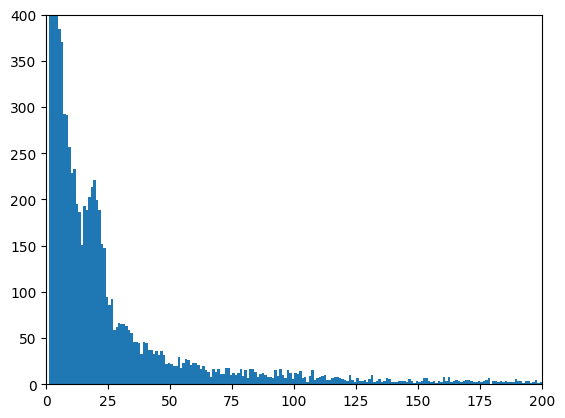

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.hist(file_counts, bins=range(1000))
ax.set_ylim(0, 400)
ax.set_xlim(0, 200)

In [ ]:
th_s = 10
fps = 12
skip = 20
th_frame_count = th_s * fps / skip
count = np.sum(file_counts >= th_frame_count)
print(f"{count=}")

count=np.int64(7331)


In [ ]:
import pandas as pd

root = "/media/dherrera/ElephantsWD/elephants/improve/tracks"
df = pd.DataFrame(
    data={"path": [str(p.relative_to(root)) for p in track_dirs], "count": file_counts}
)
df.sort_values("count", inplace=True, ascending=False)
df.head(50)

,path,count
310,zag_elp_cam_017/2025-05-19/000146,9262.0
10833,zag_elp_cam_019/2025-05-21/002433,8172.0
2139,zag_elp_cam_017/2025-05-24/004184,7837.0
3022,zag_elp_cam_018/2025-05-19/000366,7703.0
7007,zag_elp_cam_016/2025-05-21/002389,7240.0
7670,zag_elp_cam_016/2025-05-22/003903,7001.0
11750,zag_elp_cam_019/2025-05-24/005550,6888.0
2456,zag_elp_cam_017/2025-05-25/004780,6573.0
8492,zag_elp_cam_016/2025-05-24/005834,6522.0
4708,zag_elp_cam_018/2025-05-24/005693,6495.0
